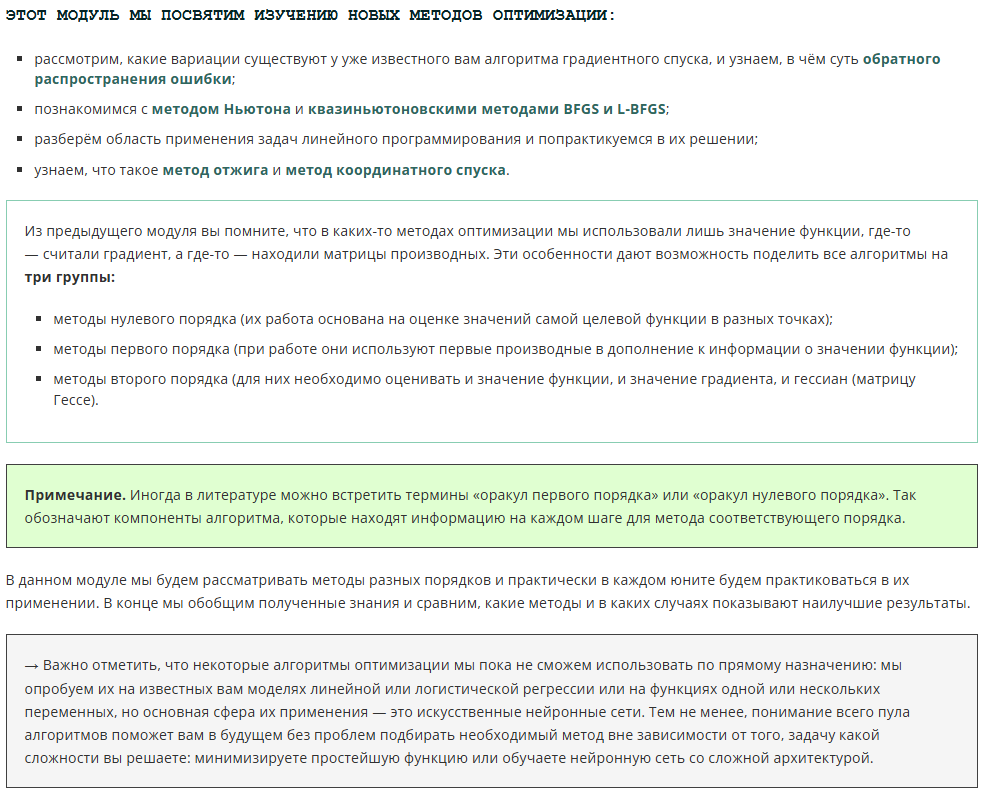

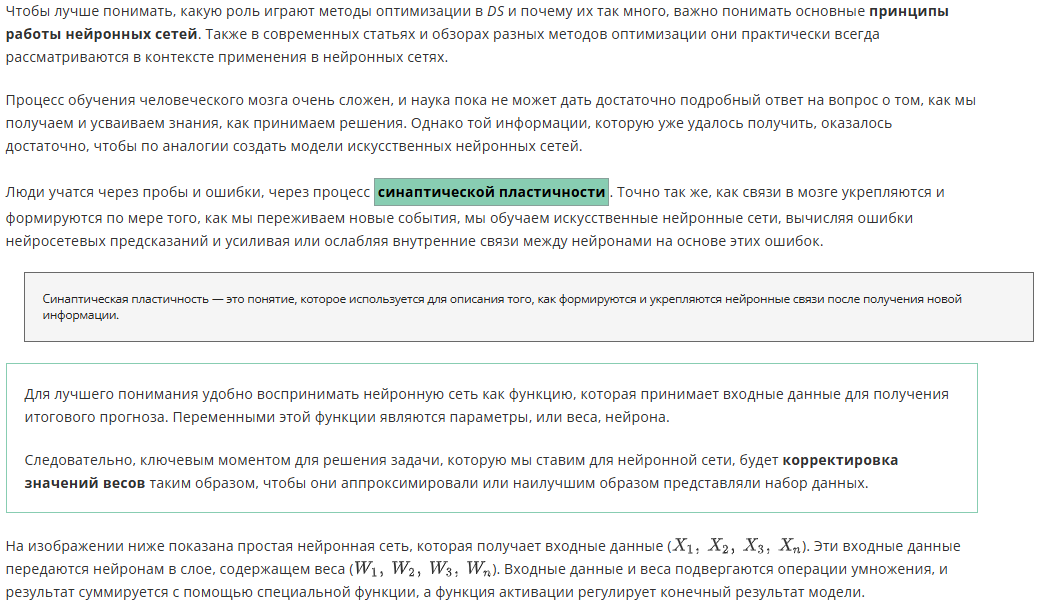

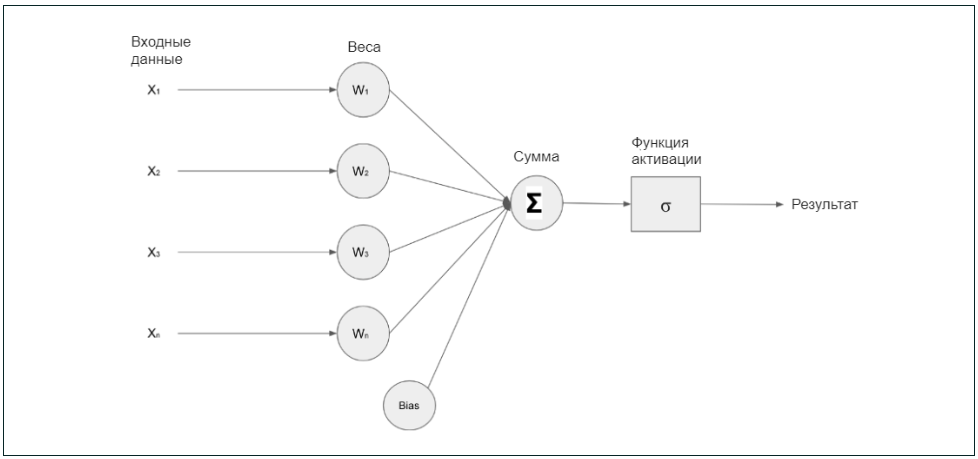

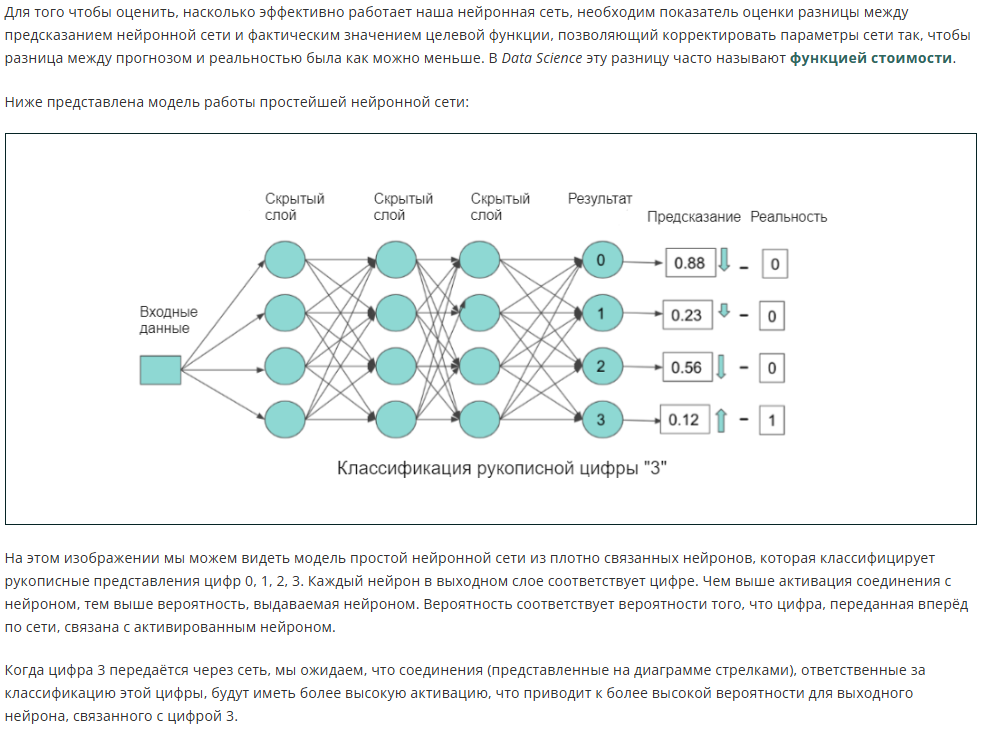

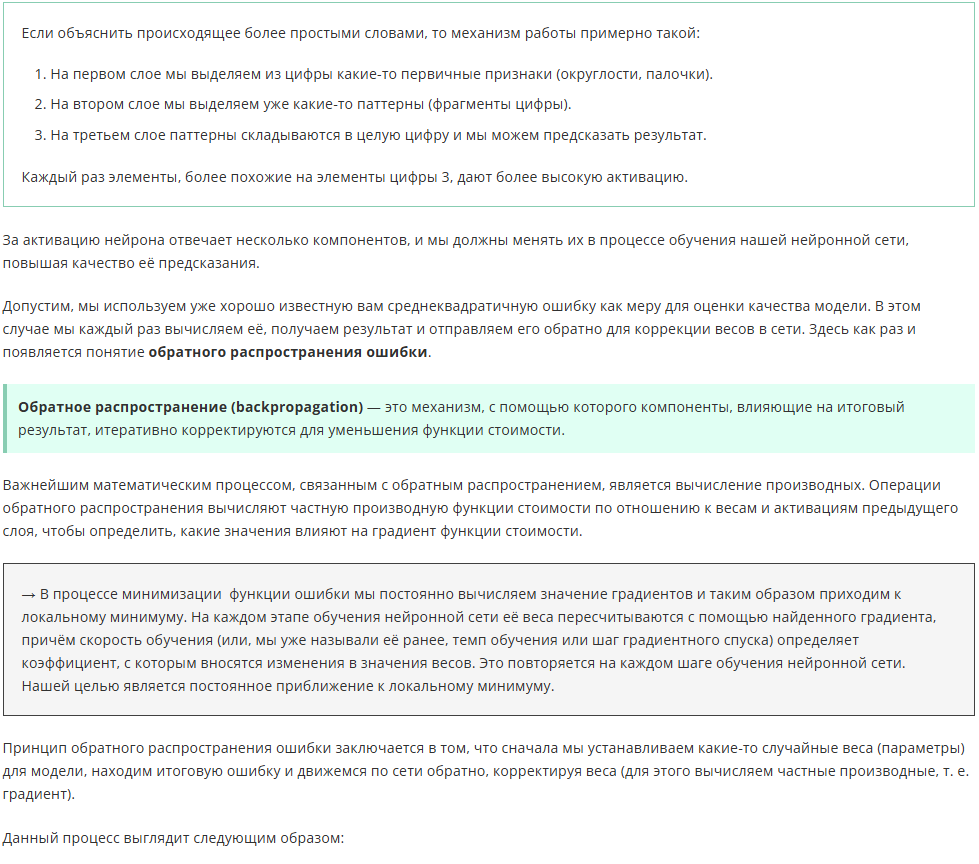

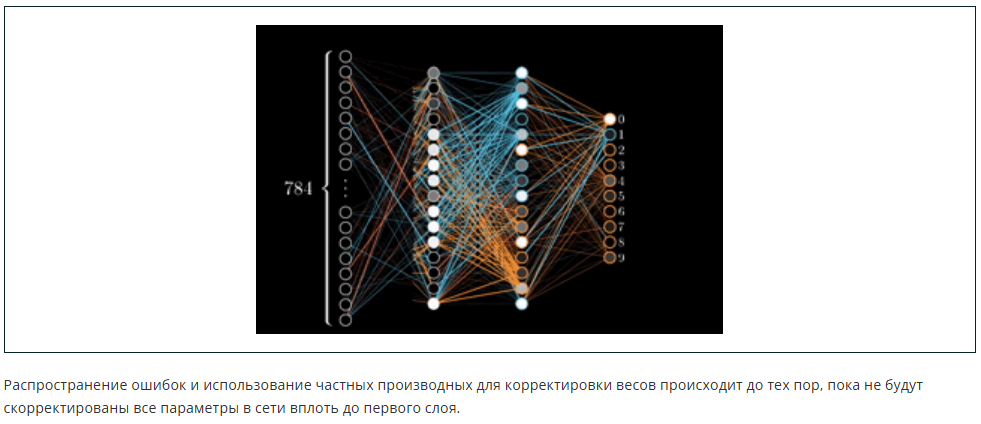

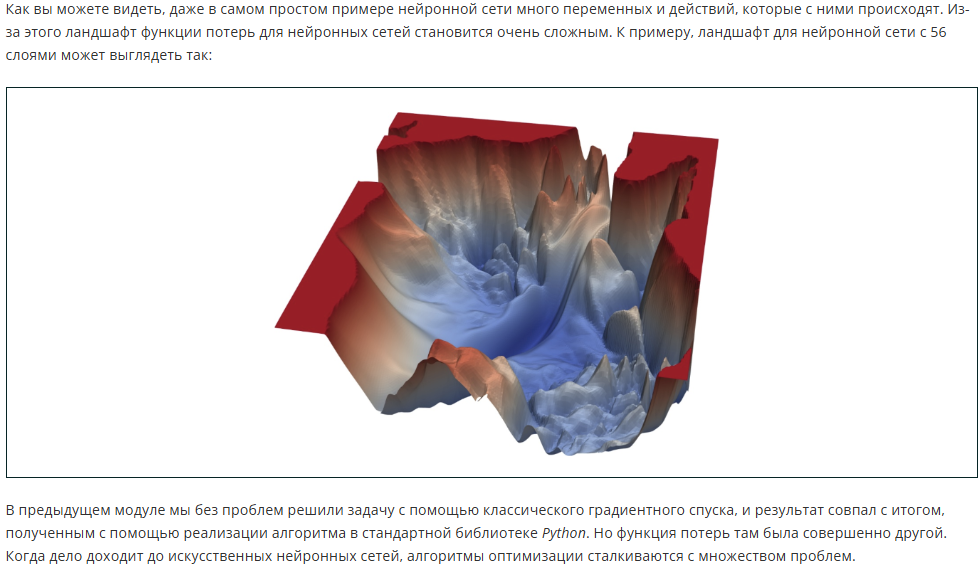

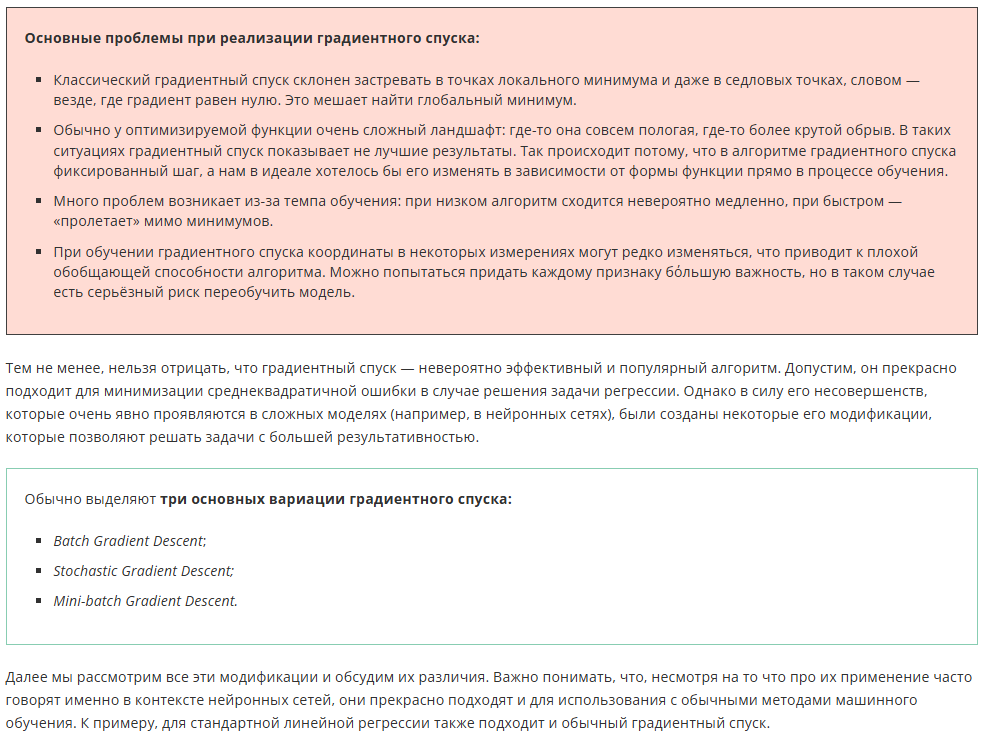

# <center> **Batch Gradient Descent**

Первая вариация — это **Batch Gradient Descent**. По-русски её называют **пакетным градиентным спуском**, или **ванильным градиентным спуском** (хотя англоязычную вариацию Vanilla Gradient Descent чаще не переводят). По сути, это и есть классический градиентный спуск, который мы с вами рассматривали в предыдущем модуле.

*Пакетным* его называют по той причине, что он использует всю выборку (весь пакет) на каждом шаге, для того чтобы получить результат.

Слово "*vanilla*" в названии используют для того, чтобы указать, что это самый простой вариант, без «примесей». В английском языке такое название может применяться не только для градиентного спуска, но и для любого метода в целом. В русском языке такое название, как правило, чаще присутствует в дословных переводах англоязычных текстов.

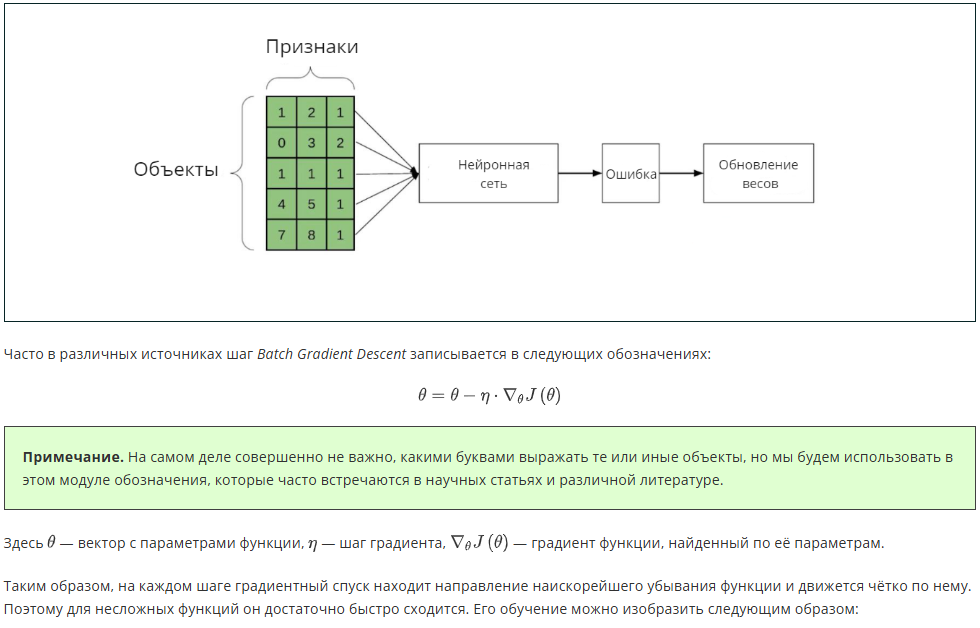

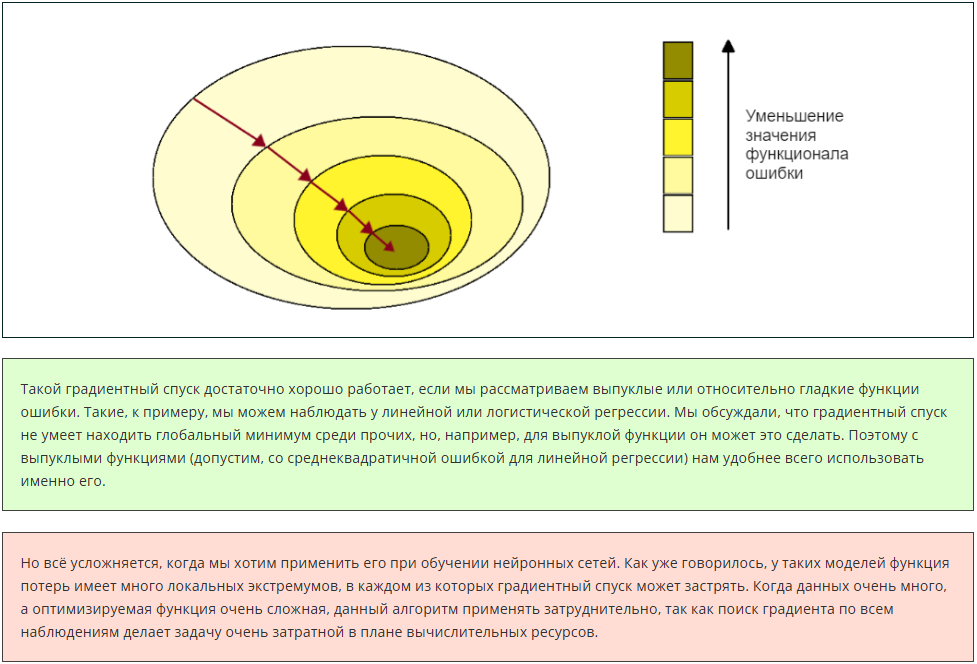

# <center> **Stochastic Gradient Descent**

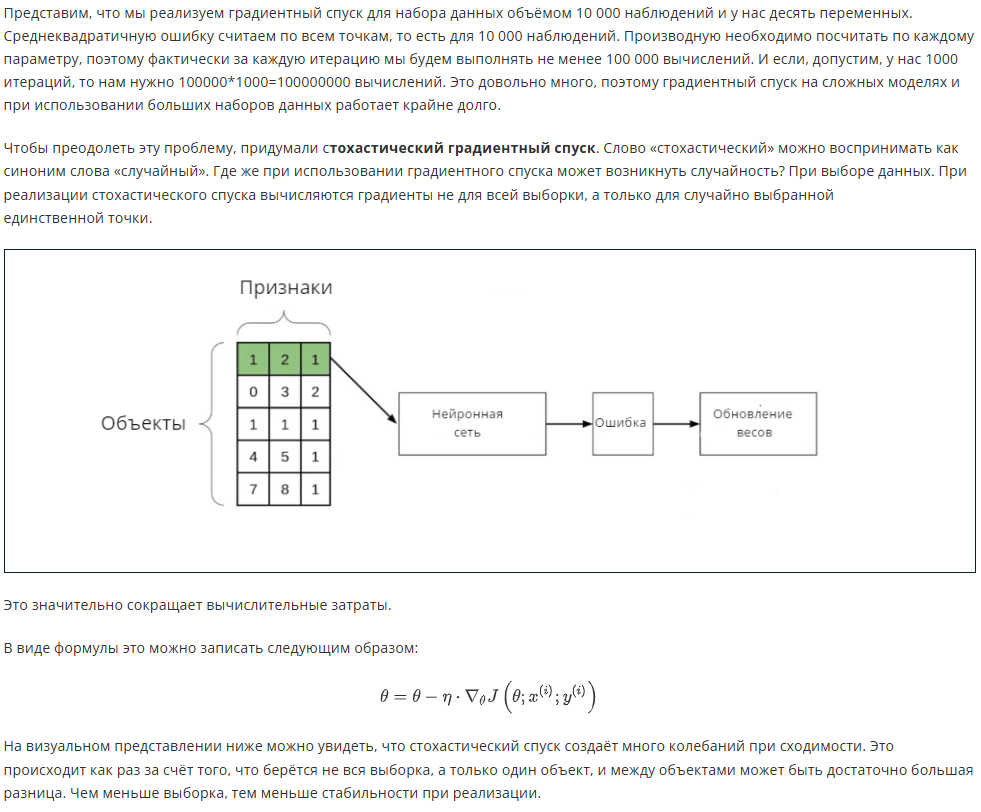

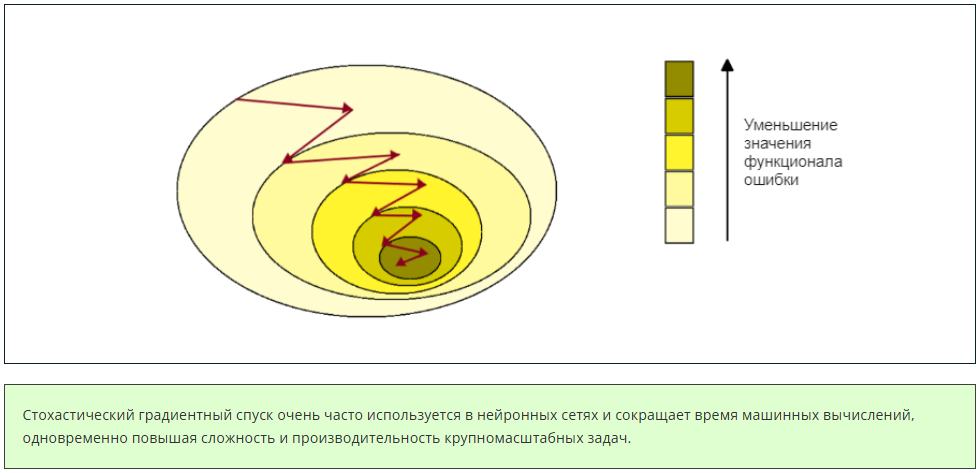

# <center> **Mini-batch Gradient Descent**

Третья вариация градиентного спуска — **Mini-batch Gradient Descent**. Также можно называть его **мини-пакетным градиентным спуском**. По сути, эта модификация сочетает в себе лучшее от классической реализации и стохастического варианта. На данный момент это наиболее популярная реализация градиентного спуска, которая используется в глубоком обучении (т. е. в обучении нейронных сетей).

В ходе обучения модели с помощью мини-пакетного градиентного спуска обучающая выборка разбивается на пакеты (**батчи**), для которых рассчитывается ошибка модели и пересчитываются веса.

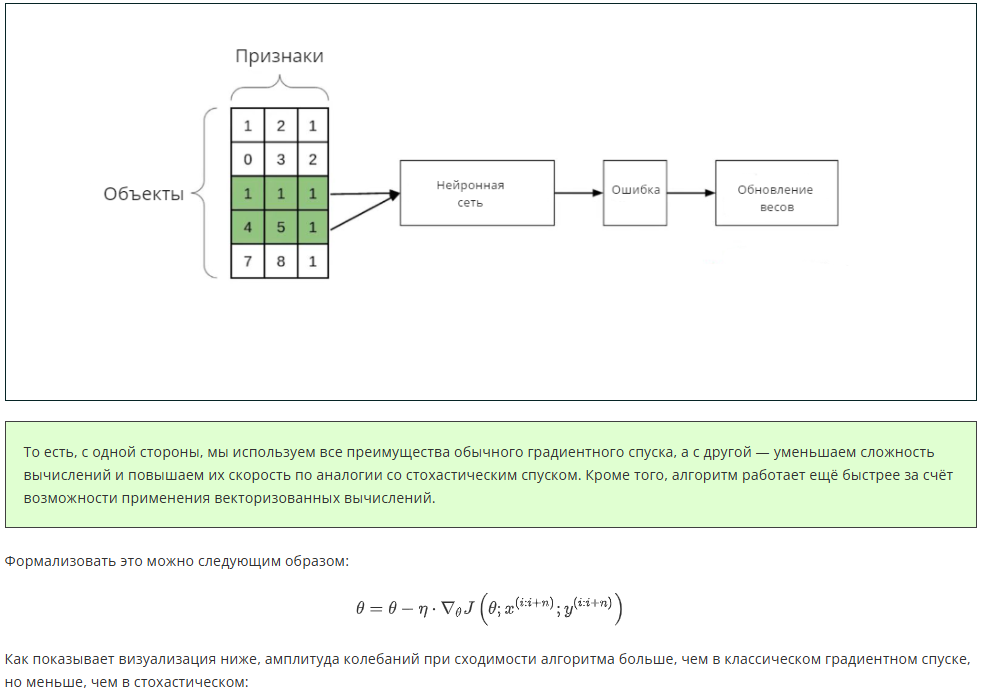

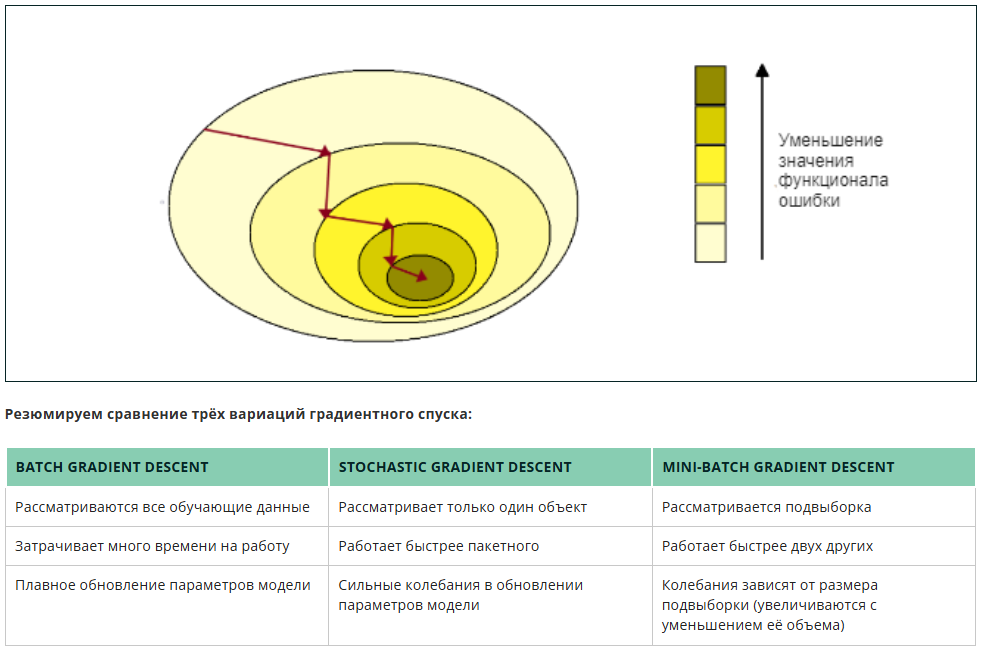

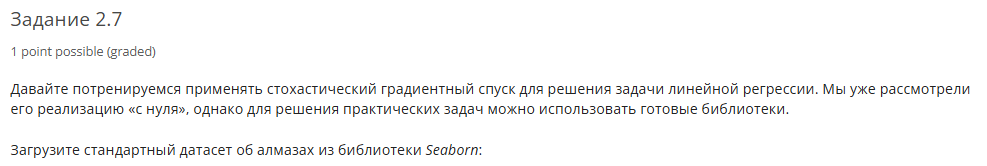

In [10]:
import seaborn as sns
import pandas as pd
import numpy as np
df = sns.load_dataset('diamonds')

Удалите часть признаков:

In [11]:
df.drop(['depth', 'table', 'x', 'y', 'z'], axis=1, inplace=True)

Закодируйте категориальные признаки:

In [12]:
df = pd.get_dummies(df, drop_first=True)

Логарифмируйте признаки:

In [13]:
df['carat'] = np.log(1+df['carat'])
df['price'] = np.log(1+df['price'])

Определите целевую переменную и предикторы:

In [14]:
X = df.drop(columns="price")
y = df["price"]

Разделите выборку на обучающую и тестовую (объём тестовой возьмите равным 0.33), значение random_state должно быть равно 42.

Теперь реализуйте алгоритм линейной регрессии со стохастическим градиентным спуском (класс SGDRegressor). Отберите с помощью GridSearchCV оптимальные параметры по следующей сетке:

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import linear_model 
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y,random_state = 42, test_size = 0.33)

#Сетка параметров для отбора
param_grid = {
    "loss": ["squared_error", "epsilon_insensitive"],
    "penalty": ["elasticnet"],
    "alpha": np.logspace(-3, 3, 10),
    "l1_ratio": np.linspace(0, 1, 10),
    "learning_rate": ["constant"],
    "eta0": np.logspace(-4, -1, 4)
}
#Создаём объект класса линейной регрессии с SGD
sgd_1 = linear_model.SGDRegressor(random_state=42)

# Подбор оптимальных параметров
grid_search = GridSearchCV(
    estimator=sgd_1,
    param_grid=param_grid,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

sgd_2 = linear_model.SGDRegressor(**grid_search.best_params_,random_state=42)

sgd_2.fit(X_train, y_train)

ls = sgd_2.predict(X_test)

round(mean_squared_error(y_test, ls), 3)

{'alpha': 0.001, 'eta0': 0.001, 'l1_ratio': 0.0, 'learning_rate': 'constant', 'loss': 'epsilon_insensitive', 'penalty': 'elasticnet'}


0.044

---

# Бонус: алгоритмы, основанные на градиентном спуске

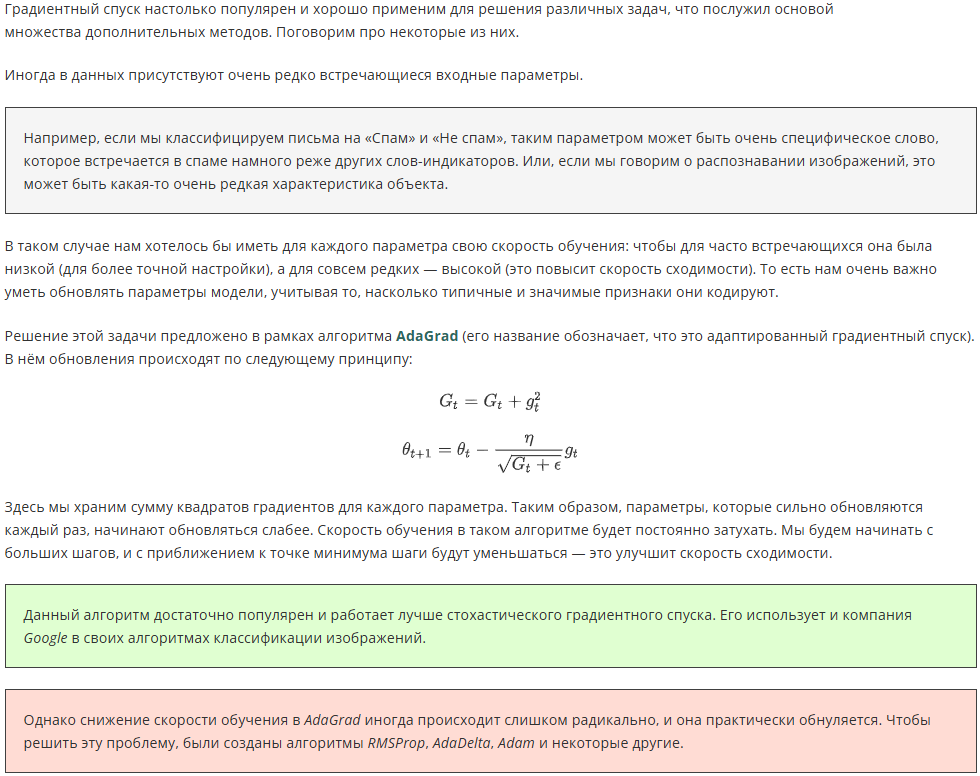

Если вам интересно подробнее узнать о перечисленных алгоритмах и окунуться в процесс оптимизации нейронных сетей, рекомендуем обратиться к следующим статьям:
* "An overview of gradient descent optimization algorithms"(скачан пдф в папке книги DS)
* [«Методы оптимизации нейронных сетей»](https://habr.com/ru/articles/318970/)

---

# <center> **Метод Ньютона**

Метод Ньютона используется во многих алгоритмах машинного обучения. Часто в литературе его сравнивают с градиентным спуском, так как два этих алгоритма очень популярны. Вы уже сталкивались с методом Ньютона, но не знали об этом.

В [документации](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) для функции ```LogisticRegression``` из библиотеки scikit-learn представлено пять вариантов алгоритмов оптимизации, которые можно использовать при обучении модели:
* 'newton-cg';
* 'lbfgs';
* 'liblinear';
* 'sag';
* 'saga'.

Последние два являются вариациями стохастического градиентного спуска (а значит вам уже понятен принцип их работы), а с первыми тремя нам только предстоит познакомиться. В этом юните мы рассмотрим алгоритм ```'newton-cg'```, в следующем — ```'lbfgs'```, а в седьмом юните — ```'liblinear'```. Вы будете понимать суть всех методов, представленных в самой популярной библиотеке для машинного обучения, и выбирать подходящий, исходя из особенностей поставленной задачи.

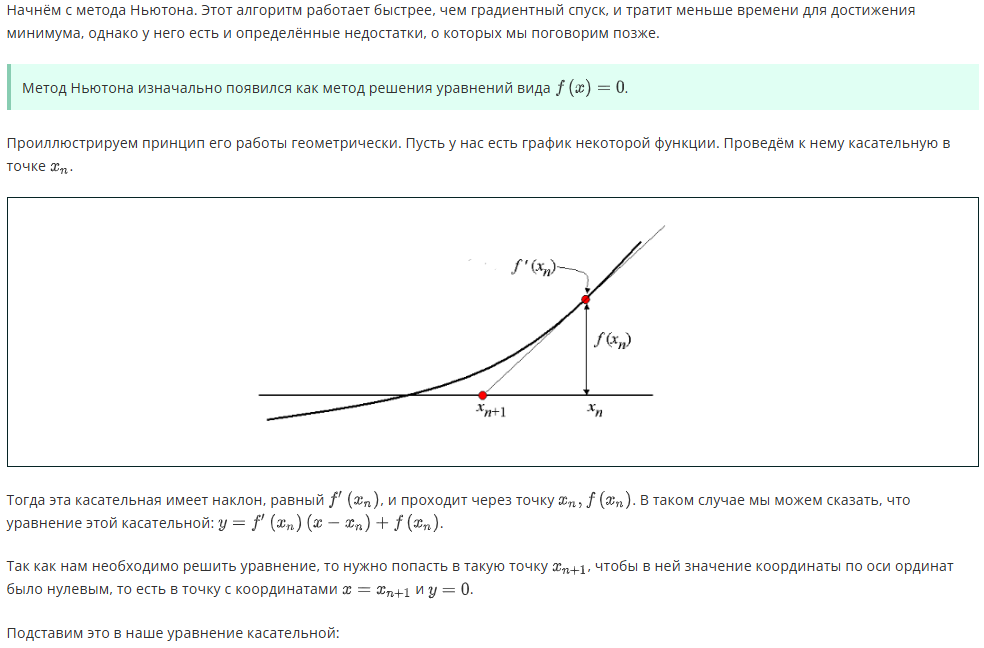

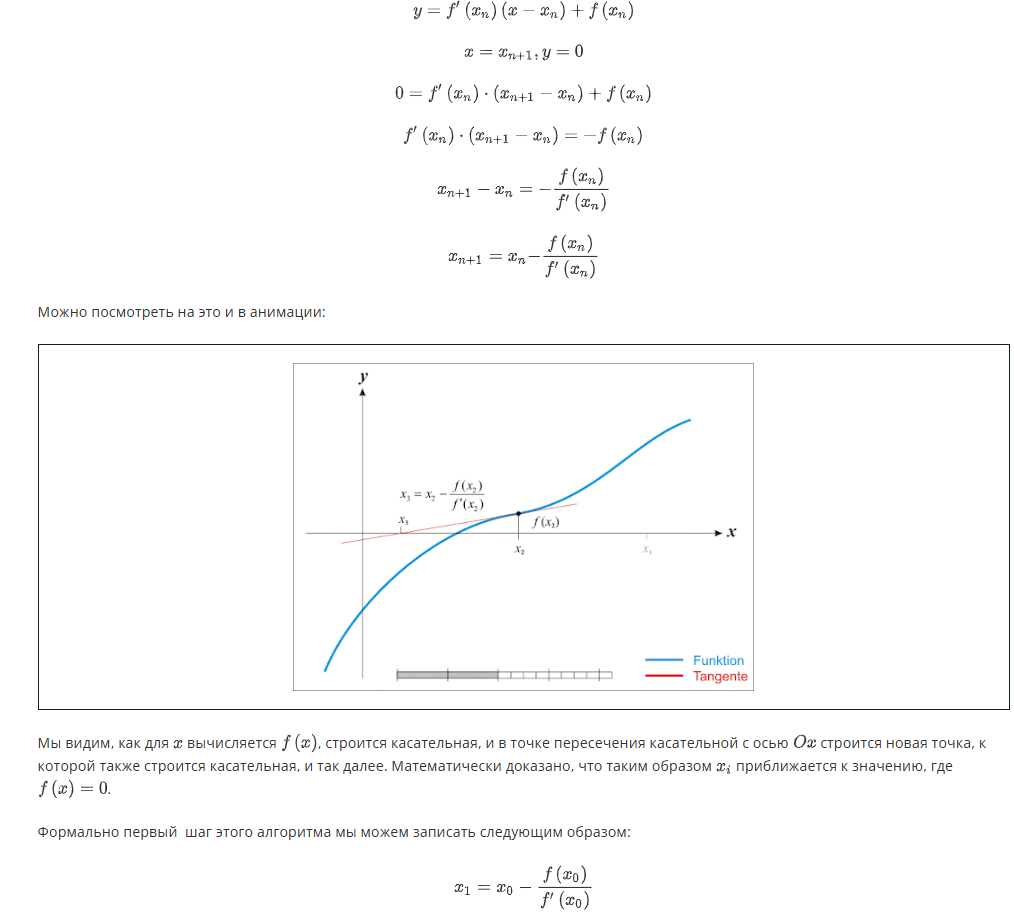

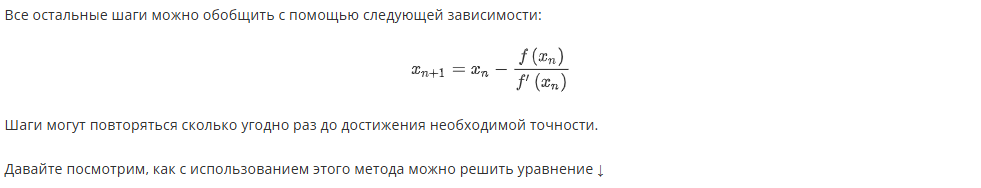

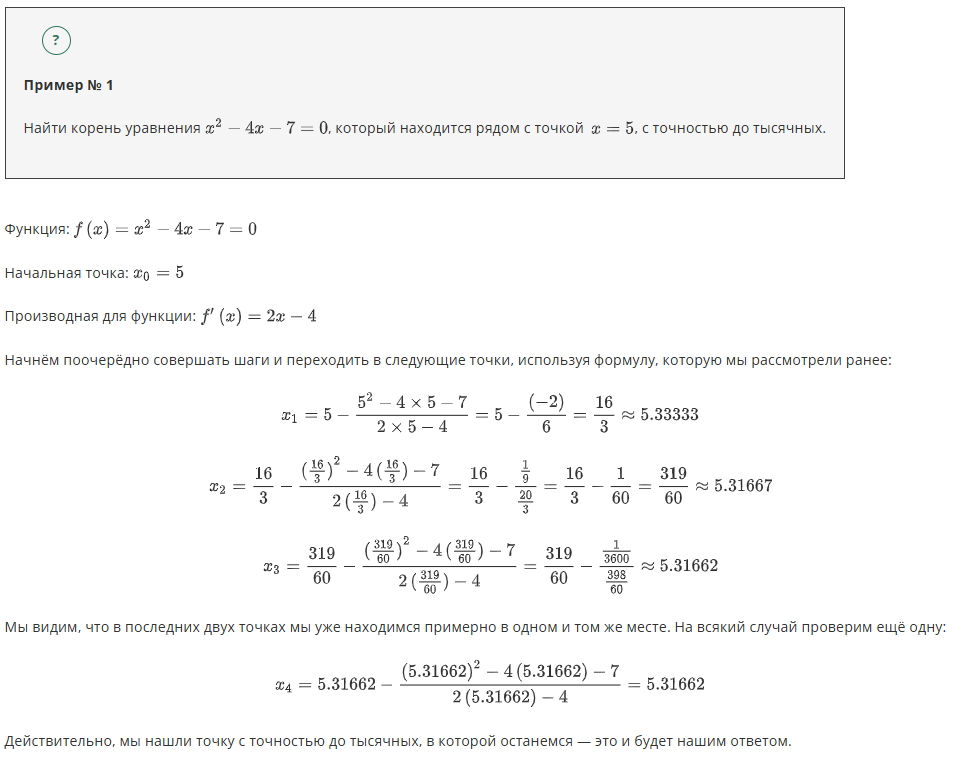

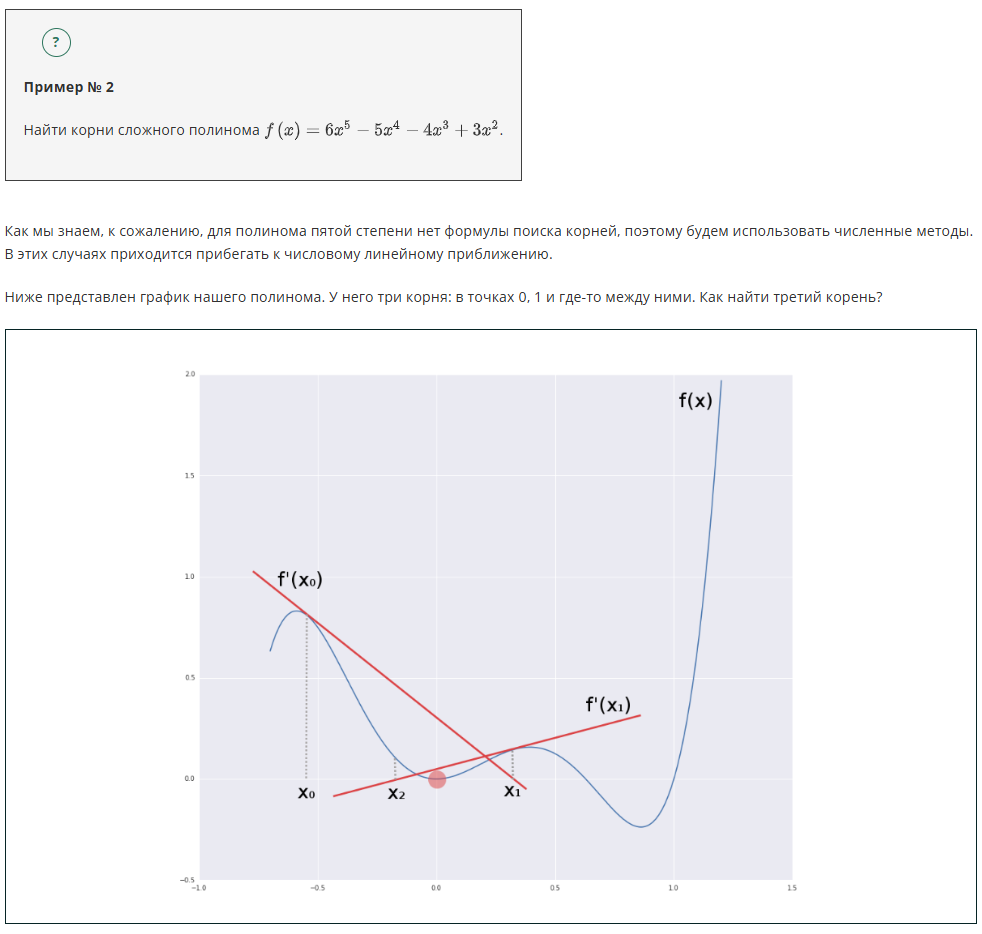

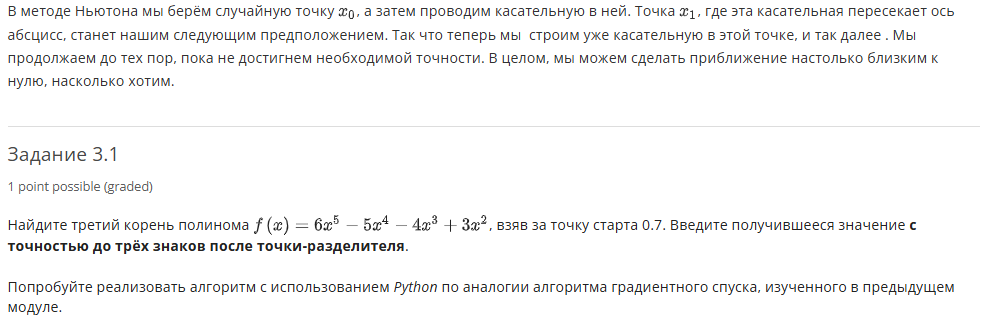

In [21]:
def fun(x):
    return 6*x**5 - 5*x**4 - 4*x**3 + 3*x**2

def grad(x):
    dx=30*x**4 - 20*x**3 - 12*x**2 + 6*x
    return dx

In [39]:
x_0=0.7
x_list = [0.7]
i = 0
while True:
    x_new=x_0 - fun(x_0)/grad(x_0)
    x_new=round(x_new,4)
    x_list.append(x_new)
    x_0=x_new
    i += 1
    print(f"iter={i}; x_list: {x_list}")
    if x_list[-1]==x_list[-2]:
        break

iter=1; x_list: [0.7, 0.6296]
iter=2; x_list: [0.7, 0.6296, 0.6287]
iter=3; x_list: [0.7, 0.6296, 0.6287, 0.6287]


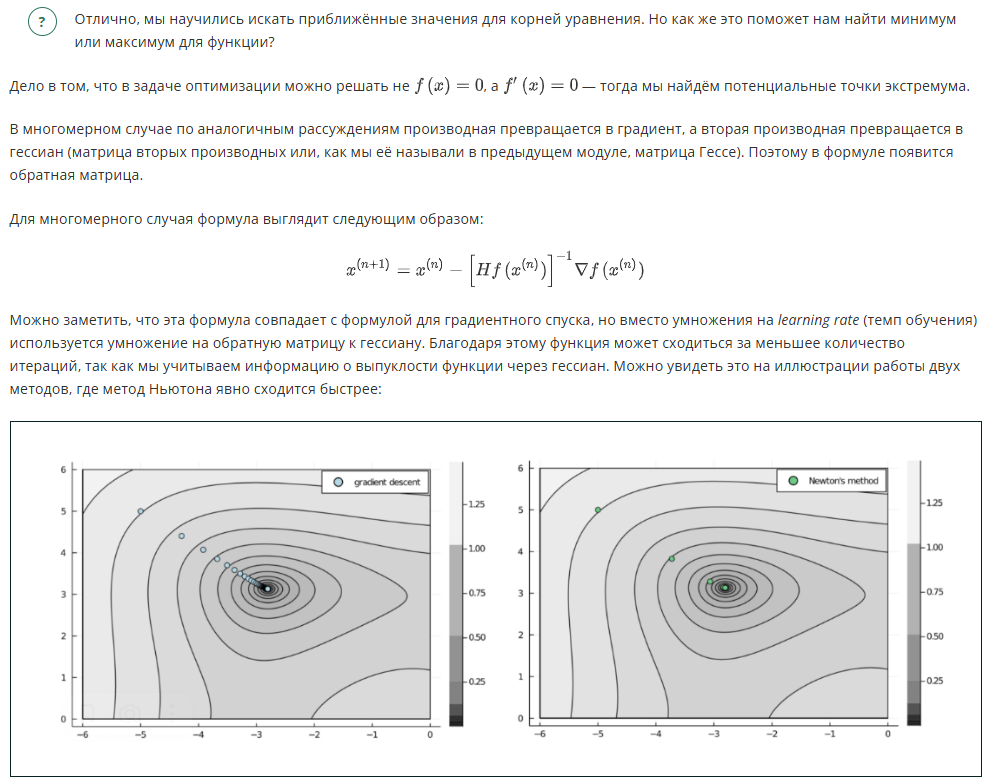

Метод Ньютона, если считать в количестве итераций, в многомерном случае (с гессианом) работает быстрее градиентного спуска.

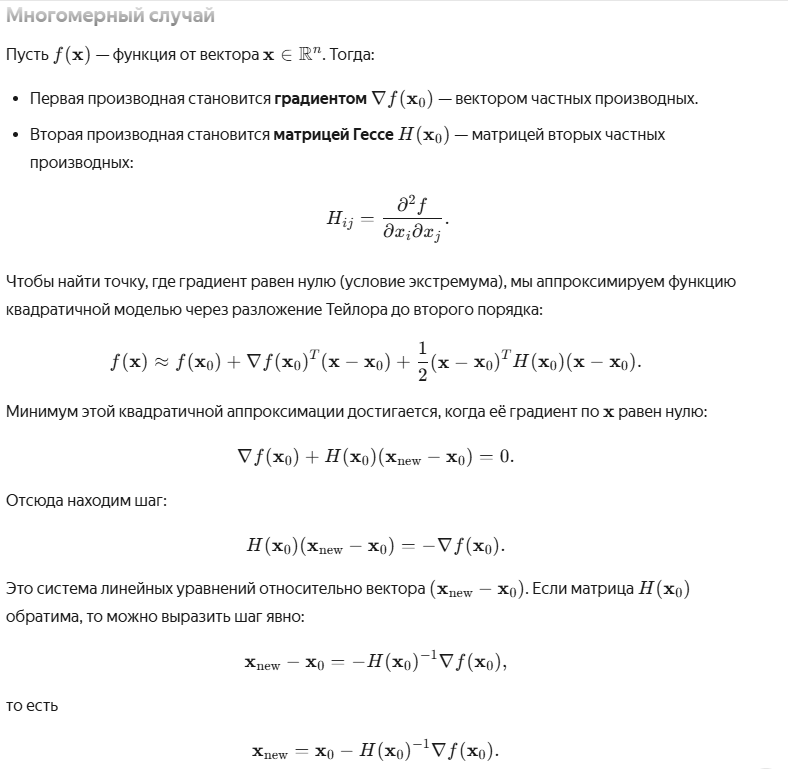

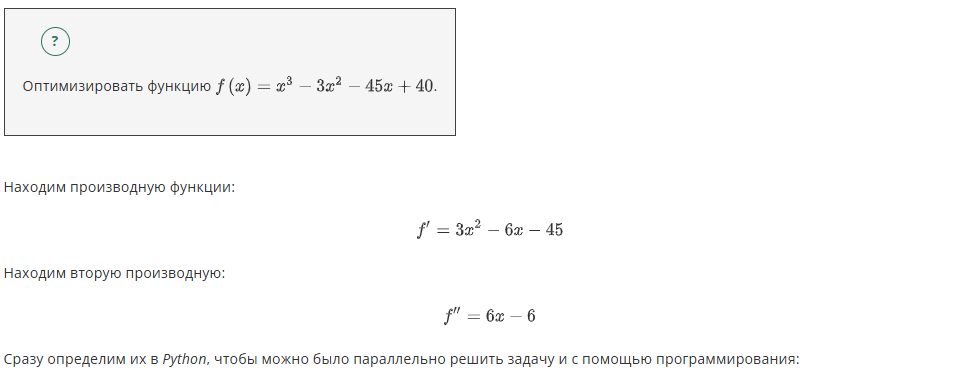

In [40]:
def func1(x):
    return 3*x**2 - 6*x -45
def func2(x):
    return 6*x - 6

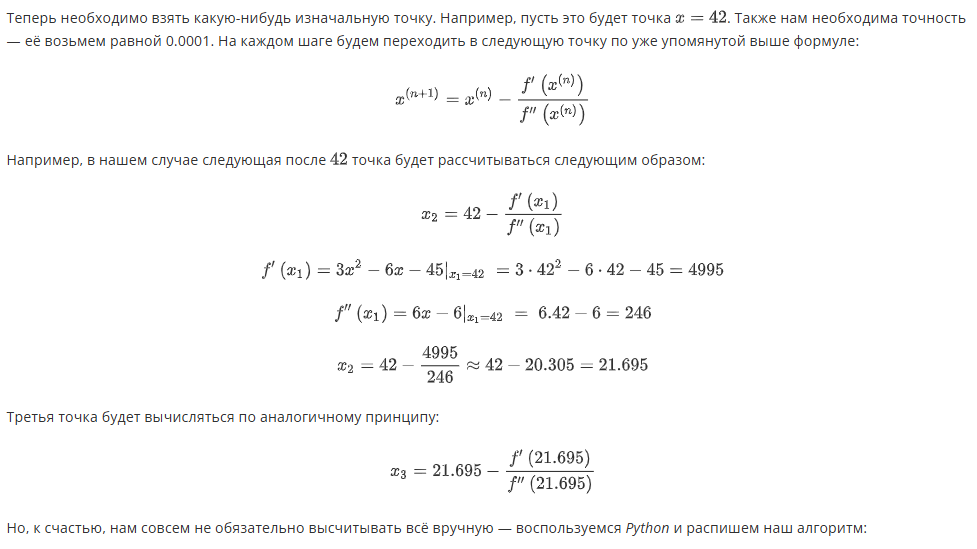

In [41]:
initial_value = 42
iter_count = 0
x_curr = initial_value
epsilon = 0.0001
f = func1(x_curr)

while (abs(f) > epsilon):
    f = func1(x_curr)
    f_prime = func2(x_curr)
    x_curr = x_curr - (f)/(f_prime)
    iter_count += 1
    print(x_curr)

21.695121951219512
11.734125501243229
7.1123493600499685
5.365000391507974
5.015260627016227
5.000029000201801
5.000000000105126
5.000000000000001


Можно объединить всё в одну функцию:

In [42]:
def newtons_method(f, fprime, x0, tol=0.0001):
    iter_count = 0
    x_curr = x0
    f_val = f(x_curr)
    while (abs(f_val) > tol):
        f_val = f(x_curr)
        f_prime_val = fprime(x_curr)
        x_curr = x_curr - (f_val)/(f_prime_val)
        iter_count += 1
    return x_curr

newtons_method(f=func1, fprime=func2, x0=50, tol=0.0001)

5.0

А можно воспользоваться реализацией из библиотеки scipy:

In [43]:
from scipy.optimize import newton
newton(func=func1, fprime=func2, x0=50, tol=0.0001)

5.0

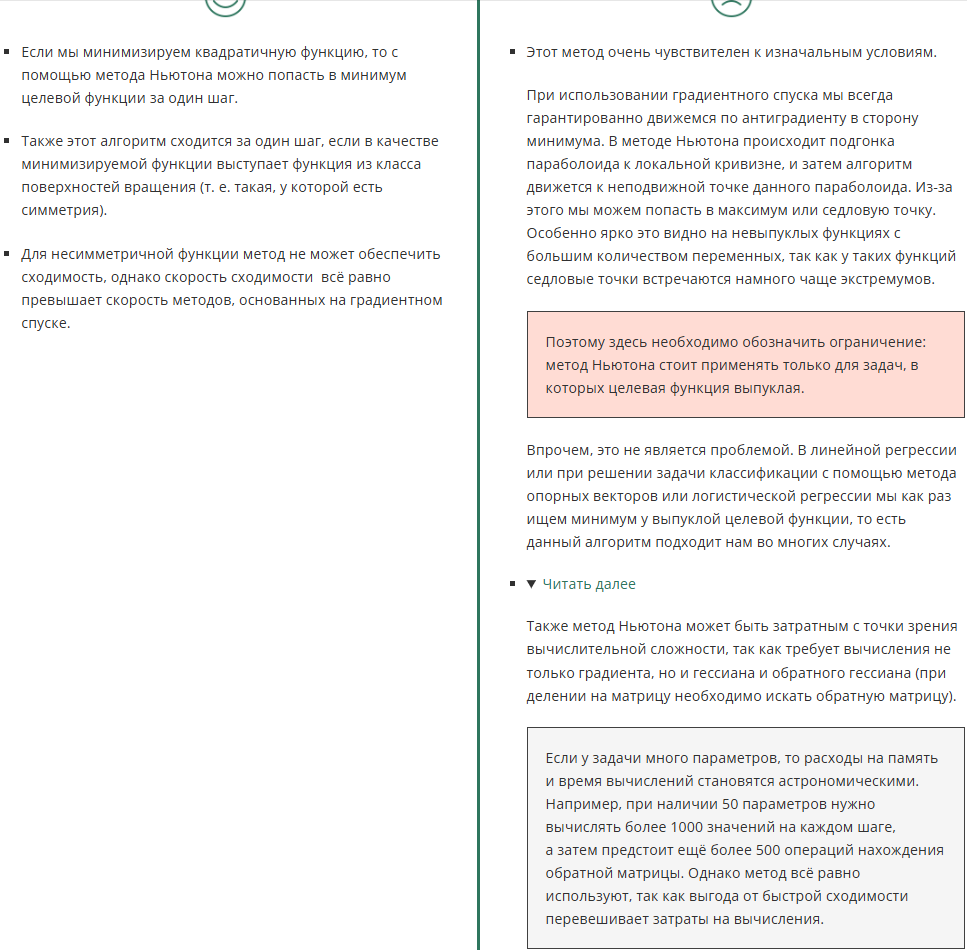

Несмотря на его ограниченное практическое применение, метод Ньютона по-прежнему представляет большую ценность. Он имеет большое преимущество перед градиентным спуском в силу своей быстроты и отсутствия необходимости в настройке гиперпараметра шага (мы помним, что в градиентном спуске выбор шага — довольно непростая задача, а здесь можно обойтись без этого). Причём преимущество в быстроте очень ощутимое: [в сравнении на реальных данных](https://www.researchgate.net/publication/352122891_Application_of_Newton's_method_to_solve_optimization_geodetic_tasks) метод Ньютона находит решение задачи за 3 итерации, а градиентный спуск — за 489. То есть мы сильно выигрываем в скорости сходимости, а для анализа данных это очень важно, ведь экономия времени и вычислительных ресурсов позволяет решать задачи быстрее.

Мы увидели, какой эффективной может быть оптимизация второго порядка при правильном использовании. Но что, если бы мы могли каким-то образом использовать эффективность, полученную при использовании производных второго порядка, но при этом избежать вычислительных затрат на вычисление обратного гессиана? Другими словами — можем ли мы создать алгоритм, который будет своего рода гибридом между градиентным спуском и методом Ньютона, где мы сможем получать более быструю сходимость, чем градиентный спуск, но меньшие вычислительные затраты на каждую итерацию, чем в методе Ньютона?

Оказывается, такой алгоритм существует. Точнее, целый класс таких методов оптимизации, называемых **квазиньютоновскими методами**

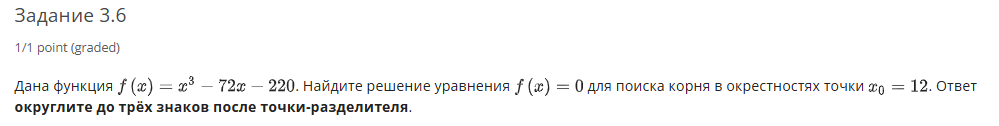

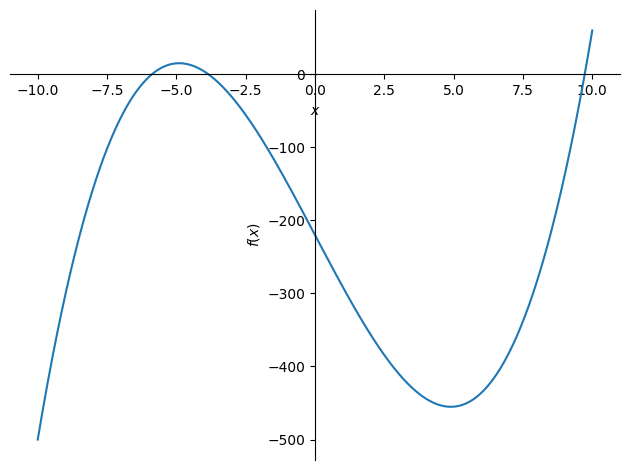

In [46]:
from sympy import *
x = symbols('x')
f = x**3 - 72*x - 220
plot(f)

In [50]:
def fun(x):
    return x**3 - 72 * x - 220

def grad(x):
    dx=3*x**2 - 72
    return dx

In [51]:
x_0=12
x_list = [12]
i = 0
while True:
    x_new=x_0 - fun(x_0)/grad(x_0)
    x_new=round(x_new,3)
    x_list.append(x_new)
    x_0=x_new
    i += 1
    print(f"iter={i}; x_list: {x_list}")
    if x_list[-1]==x_list[-2]:
        break

iter=1; x_list: [12, 10.211]
iter=2; x_list: [12, 10.211, 9.756]
iter=3; x_list: [12, 10.211, 9.756, 9.727]
iter=4; x_list: [12, 10.211, 9.756, 9.727, 9.727]


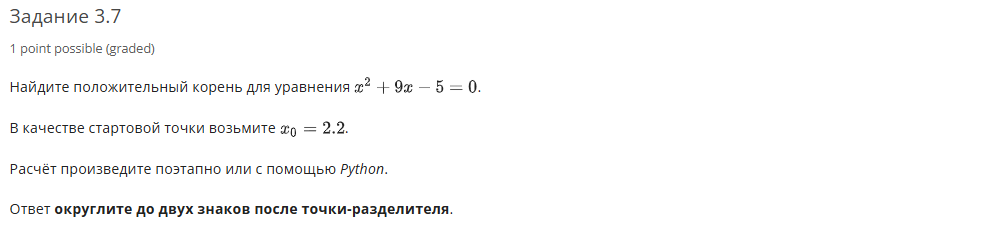

In [57]:
def fun(x):
    return x**2 + 9 * x - 5

def grad(x):
    dx=32*x + 9
    return dx

x_0=2.2
x_list = [2.2]
i = 0
while True:
    x_new=x_0 - fun(x_0)/grad(x_0)
    x_new=round(x_new,3)
    x_list.append(x_new)
    x_0=x_new
    i += 1
    print(f"iter={i}; x_list: {x_list}")
    if x_list[-1]==x_list[-2]:
        break

iter=1; x_list: [2.2, 1.953]
iter=2; x_list: [2.2, 1.953, 1.724]
iter=3; x_list: [2.2, 1.953, 1.724, 1.514]
iter=4; x_list: [2.2, 1.953, 1.724, 1.514, 1.324]
iter=5; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155]
iter=6; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009]
iter=7; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885]
iter=8; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785]
iter=9; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785, 0.706]
iter=10; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785, 0.706, 0.647]
iter=11; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785, 0.706, 0.647, 0.605]
iter=12; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785, 0.706, 0.647, 0.605, 0.576]
iter=13; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785, 0.706, 0.647, 0.605, 0.576, 0.557]
iter=14; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0

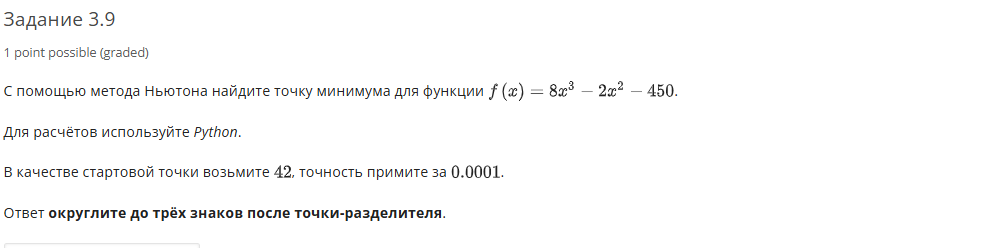

In [68]:
def newtons_method(f, fprime, x0, tol=0.0001):
    iter_count = 0
    x_curr = x0
    f_val = f(x_curr)
    while (abs(f_val) > tol):
        f_val = f(x_curr)
        f_prime_val = fprime(x_curr)
        x_curr = x_curr - (f_val)/(f_prime_val)
        iter_count += 1
    return round(x_curr, 3)

def func1(x):
    return 24*x**2 - 4*x 
def func2(x):
    return 48*x - 4

newtons_method(f=func1, fprime=func2, x0=42, tol=0.0001)

0.167

---